# Bank Term Deposit Amount Prediction

This notebook presents an end-to-end regression workflow for estimating expected term deposit value per client.

**Business objective:** estimate the expected term deposit amount for each client and use model outputs to prioritize high-value marketing leads under budget constraints.

The workflow uses client, financial, and campaign-related information available before outreach, then compares multiple regression approaches and evaluates campaign targeting strategies.

## Final Verified Results

The final model is a two-stage XGBoost expected-value model:

1. Estimate probability of subscribing.
2. Estimate deposit amount conditional on subscribing.
3. Multiply both values to estimate expected deposit per client.

| Metric | Value |
|---|---:|
| RMSE | 798.45 |
| MAE | 359.42 |
| R² | 0.3578 |
| Subscription classifier ROC-AUC | 0.8078 |
| Subscription classifier PR-AUC | 0.4723 |

Campaign simulation result: targeting the top 20% ranked clients produced about **3.77x** higher actual deposit value than random 20% targeting.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor, XGBClassifier

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_CANDIDATES = [
    Path("bank-full.csv"),
    Path("data/raw/bank-full.csv"),
    Path("../data/raw/bank-full.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find bank-full.csv. Expected it in the repo root or data/raw/.")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## Load and Understand the Dataset

The project uses a bank marketing dataset provided during my internship. Since actual deposit amounts are not included, a realistic `deposit_amount` target is simulated for project purposes.

In [2]:
df_raw = pd.read_csv(DATA_PATH, sep=";")
print(f"Shape: {df_raw.shape}")
display(df_raw.head())

audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "unknown_count": (df_raw == "unknown").sum(),
    "n_unique": df_raw.nunique(),
})
display(audit)

print("Subscription target distribution:")
display(df_raw["y"].value_counts(normalize=True).rename("rate").to_frame())

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


,dtype,missing,unknown_count,n_unique
age,int64,0,0,77
job,object,0,288,12
marital,object,0,0,3
education,object,0,1857,4
default,object,0,0,2
balance,int64,0,0,7168
housing,object,0,0,2
loan,object,0,0,2
contact,object,0,13020,3
day,int64,0,0,31


Subscription target distribution:


,rate
y,
no,0.883015
yes,0.116985


## Data Cleaning Choices

`unknown` values are retained as their own category instead of being deleted. In marketing data, unknown contact or previous campaign outcome can itself carry signal. Numeric outliers are not removed globally; instead, feature engineering clips or transforms values where appropriate. This avoids dropping many valid customers.

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


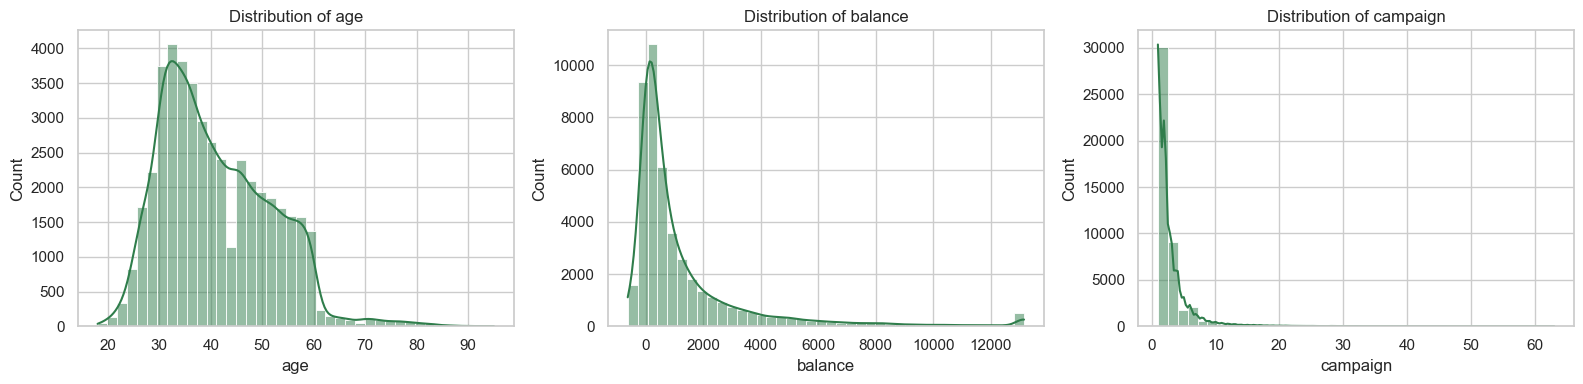

In [3]:
print("Numeric summary:")
display(df_raw.describe().T)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["age", "balance", "campaign"]):
    values = df_raw[col]
    if col == "balance":
        values = values.clip(values.quantile(0.01), values.quantile(0.99))
    sns.histplot(values, bins=40, kde=True, ax=ax, color="#2f7d4b")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

## Target Simulation: `deposit_amount`

The source dataset has a binary subscription target `y`, but no deposit amount. The simulated target follows these rules:

- Clients with `y = no` receive `deposit_amount = 0`.
- Clients with `y = yes` receive a positive amount based on balance, age, job, education, loan/housing status, previous campaign outcome, campaign intensity, and random noise.
- Job and education multipliers represent plausible earning/deposit capacity differences.
- Random log-normal and normal noise adds natural customer-level variance.

The target uses `y` only for simulation. The model is not allowed to use `y` as a feature.

In [4]:
def simulate_deposit_amount(df, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    d = df.copy()

    positive_balance = np.clip(d["balance"].to_numpy(dtype=float), 0, None)
    log_balance = np.log1p(positive_balance)
    age = d["age"].to_numpy(dtype=float)
    campaign = np.clip(d["campaign"].to_numpy(dtype=float), 1, None)
    previous = d["previous"].to_numpy(dtype=float)
    pdays = d["pdays"].to_numpy(dtype=float)

    job_multiplier = d["job"].map({
        "management": 1.35,
        "entrepreneur": 1.30,
        "retired": 1.25,
        "self-employed": 1.18,
        "technician": 1.08,
        "admin.": 1.00,
        "services": 0.92,
        "blue-collar": 0.82,
        "housemaid": 0.85,
        "student": 0.72,
        "unemployed": 0.70,
        "unknown": 0.90,
    }).fillna(1.0).to_numpy()

    education_multiplier = d["education"].map({
        "tertiary": 1.18,
        "secondary": 1.00,
        "primary": 0.82,
        "unknown": 0.92,
    }).fillna(1.0).to_numpy()

    loan_multiplier = np.where(d["loan"].eq("yes"), 0.82, 1.00)
    housing_multiplier = np.where(d["housing"].eq("yes"), 0.92, 1.00)
    prior_success_multiplier = np.where(d["poutcome"].eq("success"), 1.35, 1.00)
    previous_contact_multiplier = np.where(previous > 0, 1.08, 1.00)
    recency_multiplier = np.where((pdays > 0) & (pdays <= 90), 1.10, 1.00)
    campaign_penalty = 1 / np.sqrt(campaign)
    age_effect = 1 + np.clip((age - 35) / 100, -0.12, 0.30)

    base_amount = 350 + 220 * log_balance + 12 * np.clip(age, 18, 95) + 140 * np.sqrt(np.clip(previous, 0, None))
    signal = (
        base_amount
        * job_multiplier
        * education_multiplier
        * loan_multiplier
        * housing_multiplier
        * prior_success_multiplier
        * previous_contact_multiplier
        * recency_multiplier
        * campaign_penalty
        * age_effect
    )

    noise = rng.lognormal(mean=0, sigma=0.28, size=len(d))
    amount = np.clip(signal * noise + rng.normal(0, 180, size=len(d)), 100, 25_000)
    return np.where(d["y"].eq("yes"), amount, 0.0)


df = df_raw.copy()
df["subscribed"] = (df["y"] == "yes").astype(int)
df["deposit_amount"] = simulate_deposit_amount(df)

display(df[["y", "subscribed", "deposit_amount"]].describe())
print("Positive deposit rate:", (df["deposit_amount"] > 0).mean().round(4))

,subscribed,deposit_amount
count,45211.000000,45211.000000
mean,0.116985,291.843960
std,0.321406,1007.728780
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,15239.491698


Positive deposit rate: 0.117


## EDA on Simulated Deposit Amount

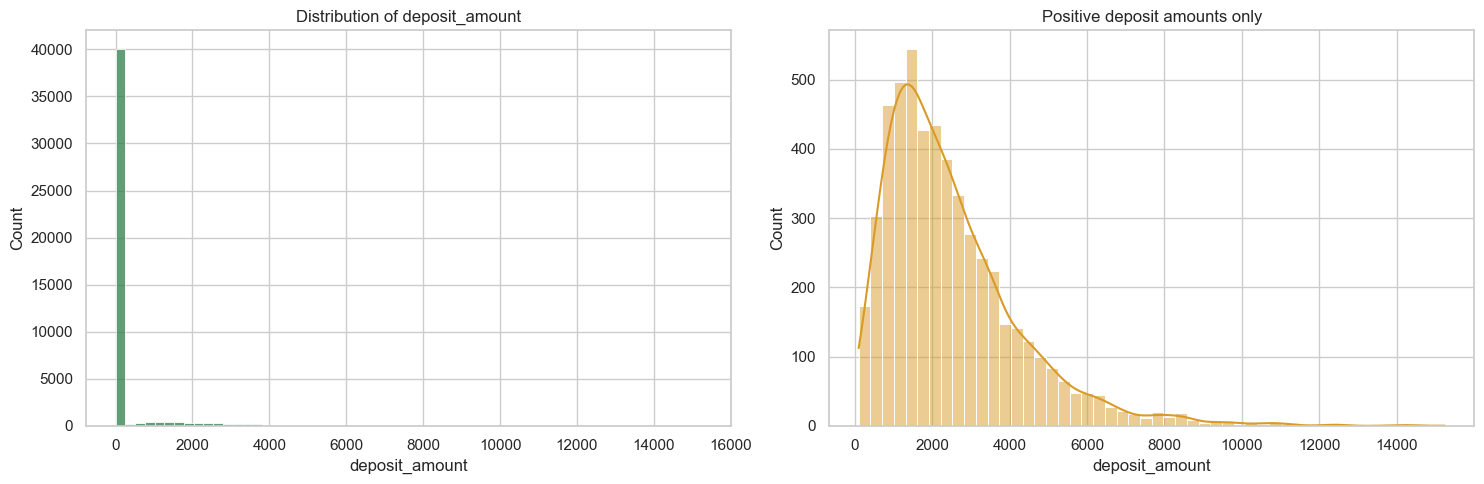

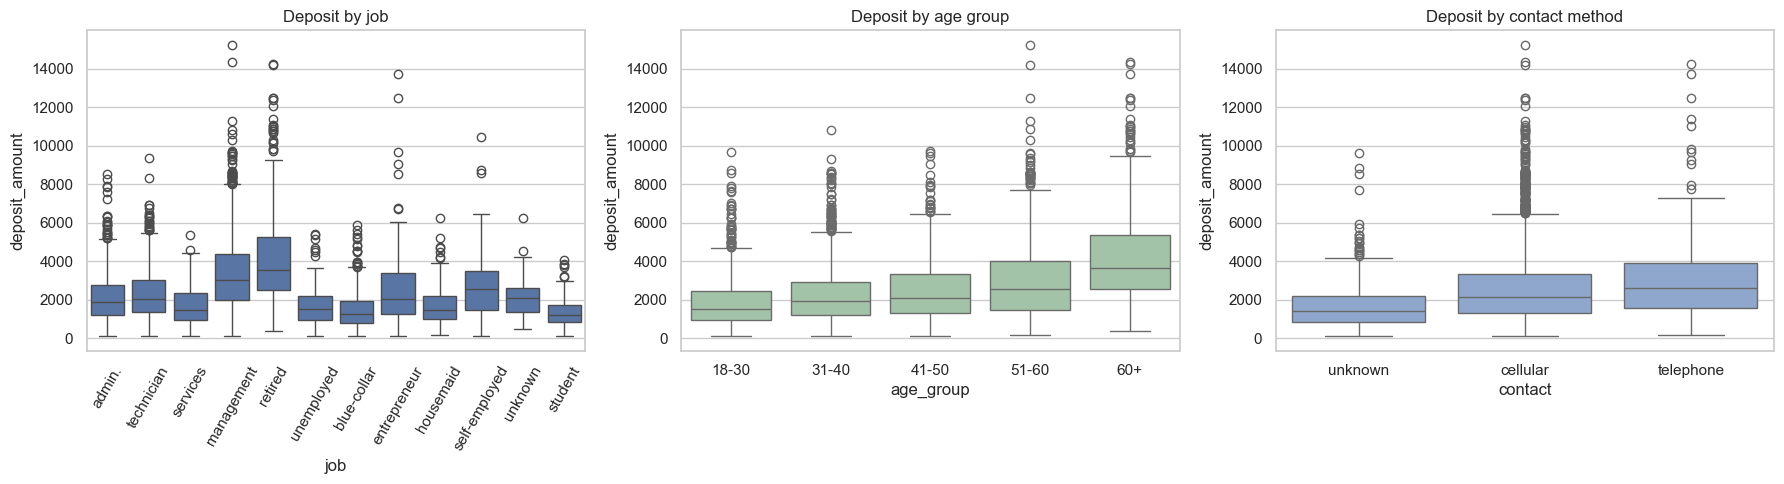

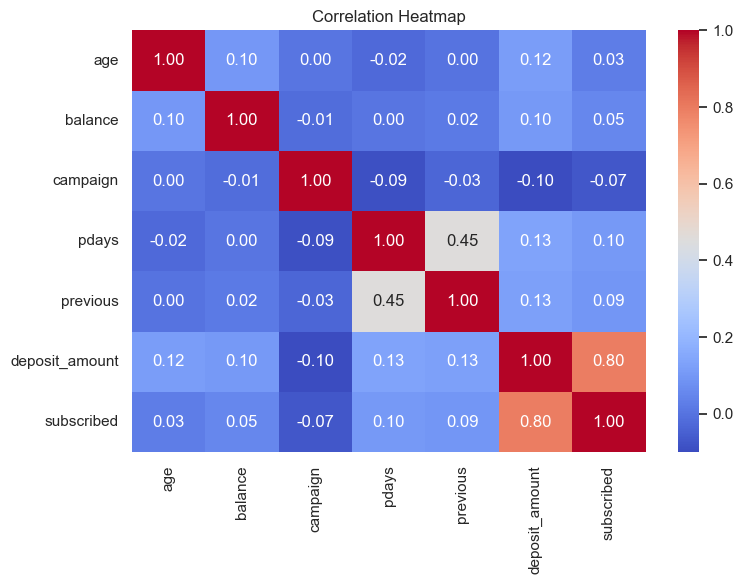

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df["deposit_amount"], bins=60, ax=axes[0], color="#2f7d4b")
axes[0].set_title("Distribution of deposit_amount")
sns.histplot(df.loc[df["deposit_amount"] > 0, "deposit_amount"], bins=50, kde=True, ax=axes[1], color="#d99a28")
axes[1].set_title("Positive deposit amounts only")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
positive = df[df["deposit_amount"] > 0].copy()
sns.boxplot(data=positive, x="job", y="deposit_amount", ax=axes[0])
axes[0].tick_params(axis="x", rotation=60)
axes[0].set_title("Deposit by job")
positive["age_group"] = pd.cut(positive["age"], bins=[17, 30, 40, 50, 60, 120], labels=["18-30", "31-40", "41-50", "51-60", "60+"])
sns.boxplot(data=positive, x="age_group", y="deposit_amount", ax=axes[1], color="#9cc9a5")
axes[1].set_title("Deposit by age group")
sns.boxplot(data=positive, x="contact", y="deposit_amount", ax=axes[2], color="#85a5d6")
axes[2].set_title("Deposit by contact method")
plt.tight_layout()
plt.show()

corr_cols = ["age", "balance", "campaign", "pdays", "previous", "deposit_amount", "subscribed"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Feature Engineering

The model uses pre-campaign client features only. The subscription outcome `y` is used for target construction and validation, while the predictive feature set focuses on information available before outreach.

In [6]:
FEATURE_COLUMNS = [
    "age", "job", "marital", "education", "default", "balance", "housing", "loan",
    "contact", "day", "month", "campaign", "pdays", "previous", "poutcome"
]

class BankFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["was_previously_contacted"] = (X["previous"] > 0).astype(int)
        X["campaign_recency_flag"] = ((X["pdays"] > 0) & (X["pdays"] <= 90)).astype(int)
        X["pdays_clean"] = X["pdays"].where(X["pdays"] >= 0, 999)
        X["contact_rate"] = (X["campaign"] / (X["pdays_clean"] + 1)).clip(0, 10)
        X["balance_positive"] = X["balance"].clip(lower=0)
        X["log_balance_positive"] = np.log1p(X["balance_positive"])
        X["has_loan_or_housing"] = ((X["loan"] == "yes") | (X["housing"] == "yes")).astype(int)
        X["age_bucket"] = pd.cut(
            X["age"],
            bins=[17, 25, 35, 45, 55, 65, 120],
            labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"],
        )
        return X


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(feature_columns):
    dummy = {c: pd.Series(dtype="object") for c in feature_columns}
    for c in ["age", "balance", "day", "campaign", "pdays", "previous"]:
        dummy[c] = pd.Series(dtype="float")
    engineered_cols = BankFeatureEngineer().transform(pd.DataFrame(dummy)).columns.tolist()

    categorical = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome", "age_bucket"]
    numeric = [c for c in engineered_cols if c not in categorical]

    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", make_one_hot_encoder())]), categorical),
    ])


def make_pipeline(model):
    return Pipeline([
        ("features", BankFeatureEngineer()),
        ("preprocess", make_preprocessor(FEATURE_COLUMNS)),
        ("model", model),
    ])

## Train / Validation / Test Split

In [7]:
X = df[FEATURE_COLUMNS].copy()
y = df["deposit_amount"].copy()
y_subscribed = df["subscribed"].copy()

X_train_full, X_test, y_train_full, y_test, sub_train_full, sub_test = train_test_split(
    X, y, y_subscribed, test_size=0.20, random_state=RANDOM_STATE, stratify=y_subscribed
)
X_train, X_val, y_train, y_val, sub_train, sub_val = train_test_split(
    X_train_full, y_train_full, sub_train_full, test_size=0.25, random_state=RANDOM_STATE, stratify=sub_train_full
)

print("Train:", X_train.shape[0], "Validation:", X_val.shape[0], "Test:", X_test.shape[0])
print("Positive rate in test:", (y_test > 0).mean().round(4))

Train: 27126 Validation: 9042 Test: 9043
Positive rate in test: 0.117


## Model Evaluation Helpers

In [8]:
def regression_metrics(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }


def evaluate_regression_model(name, pipeline):
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    metrics = regression_metrics(y_test, pred)
    metrics["model"] = name
    return metrics, pipeline, np.clip(pred, 0, None)

## Regression Model Comparison

The assignment asks for at least three regression models. This notebook compares linear, regularized linear, random forest, gradient boosting, and XGBoost models.

In [9]:
models = {
    "Linear Regression": make_pipeline(LinearRegression()),
    "Ridge Regression": make_pipeline(Ridge(alpha=10.0)),
    "Lasso Regression": make_pipeline(Lasso(alpha=0.001, max_iter=10000)),
    "Random Forest": make_pipeline(RandomForestRegressor(n_estimators=350, max_depth=18, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1)),
    "Hist Gradient Boosting": make_pipeline(HistGradientBoostingRegressor(max_iter=350, learning_rate=0.04, max_leaf_nodes=31, l2_regularization=0.01, random_state=RANDOM_STATE)),
    "XGBoost Baseline": make_pipeline(XGBRegressor(n_estimators=600, max_depth=4, learning_rate=0.035, subsample=0.9, colsample_bytree=0.85, min_child_weight=3, reg_lambda=2.0, objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1)),
}

comparison_rows = []
fitted_models = {}
test_predictions = {}
for name, pipeline in models.items():
    metrics, fitted, pred = evaluate_regression_model(name, pipeline)
    comparison_rows.append(metrics)
    fitted_models[name] = fitted
    test_predictions[name] = pred

comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE")
display(comparison_df.style.format({"RMSE": "{:.2f}", "MAE": "{:.2f}", "R2": "{:.4f}"}))

,RMSE,MAE,R2,model
5,814.69,371.88,0.3314,XGBoost Baseline
4,823.22,374.71,0.3173,Hist Gradient Boosting
3,828.47,375.72,0.3086,Random Forest
1,855.51,413.05,0.2627,Ridge Regression
0,855.56,412.49,0.2626,Linear Regression
2,855.56,412.49,0.2626,Lasso Regression


## Model Tuning

Set `RUN_TUNING = True` to rerun the randomized searches. The stored best parameters are used by default for a fast, reproducible notebook run.

In [10]:
RUN_TUNING = False

BEST_DIRECT_XGB_PARAMS = {
    "subsample": 0.9,
    "reg_lambda": 4.0,
    "reg_alpha": 0.0,
    "n_estimators": 900,
    "min_child_weight": 5,
    "max_depth": 4,
    "learning_rate": 0.025,
    "colsample_bytree": 0.75,
}

BEST_CLF_PARAMS = {
    "subsample": 0.9,
    "reg_lambda": 4,
    "n_estimators": 400,
    "min_child_weight": 1,
    "max_depth": 4,
    "learning_rate": 0.04,
    "colsample_bytree": 1.0,
}

BEST_POS_REG_PARAMS = {
    "subsample": 0.75,
    "reg_lambda": 4,
    "reg_alpha": 0.05,
    "n_estimators": 700,
    "min_child_weight": 1,
    "max_depth": 3,
    "learning_rate": 0.025,
    "colsample_bytree": 1.0,
}

if RUN_TUNING:
    direct_param_dist = {
        "model__n_estimators": [500, 700, 900],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.025, 0.04, 0.06],
        "model__subsample": [0.75, 0.9, 1.0],
        "model__colsample_bytree": [0.75, 0.9, 1.0],
        "model__min_child_weight": [1, 3, 5],
        "model__reg_lambda": [1.0, 2.0, 4.0],
        "model__reg_alpha": [0.0, 0.05, 0.2],
    }
    direct_search = RandomizedSearchCV(
        make_pipeline(XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1)),
        direct_param_dist,
        n_iter=28,
        scoring="neg_root_mean_squared_error",
        cv=3,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
    )
    direct_search.fit(X_train, y_train)
    BEST_DIRECT_XGB_PARAMS = {k.replace("model__", ""): v for k, v in direct_search.best_params_.items()}

print("Stored direct XGBoost parameters:", BEST_DIRECT_XGB_PARAMS)
print("Stored two-stage classifier parameters:", BEST_CLF_PARAMS)
print("Stored positive-amount regressor parameters:", BEST_POS_REG_PARAMS)

Stored direct XGBoost parameters: {'subsample': 0.9, 'reg_lambda': 4.0, 'reg_alpha': 0.0, 'n_estimators': 900, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.025, 'colsample_bytree': 0.75}
Stored two-stage classifier parameters: {'subsample': 0.9, 'reg_lambda': 4, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.04, 'colsample_bytree': 1.0}
Stored positive-amount regressor parameters: {'subsample': 0.75, 'reg_lambda': 4, 'reg_alpha': 0.05, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.025, 'colsample_bytree': 1.0}


## Final Direct XGBoost Model

In [11]:
direct_xgb = make_pipeline(XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, **BEST_DIRECT_XGB_PARAMS))
direct_xgb.fit(X_train, y_train)
direct_pred = np.clip(direct_xgb.predict(X_test), 0, None)
direct_metrics = regression_metrics(y_test, direct_pred)
print("Direct tuned XGBoost:", direct_metrics)

Direct tuned XGBoost: {'RMSE': 815.4445383006164, 'MAE': 371.6511884432064, 'R2': 0.33013643954209526}


## Final Two-Stage Expected-Value Model

This model performs best and is also the most natural for a zero-inflated deposit target.

In [12]:
subscription_clf = make_pipeline(XGBClassifier(objective="binary:logistic", eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1, **BEST_CLF_PARAMS))
positive_regressor = make_pipeline(XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, **BEST_POS_REG_PARAMS))

subscription_clf.fit(X_train_full, sub_train_full)
positive_regressor.fit(X_train_full[y_train_full > 0], y_train_full[y_train_full > 0])

subscription_probability = subscription_clf.predict_proba(X_test)[:, 1]
positive_amount_prediction = np.clip(positive_regressor.predict(X_test), 0, None)
two_stage_pred = subscription_probability * positive_amount_prediction

two_stage_metrics = regression_metrics(y_test, two_stage_pred)
classifier_roc_auc = roc_auc_score(sub_test, subscription_probability)
classifier_pr_auc = average_precision_score(sub_test, subscription_probability)

print("Two-stage expected-value model:", two_stage_metrics)
print(f"Subscription classifier ROC-AUC: {classifier_roc_auc:.4f}")
print(f"Subscription classifier PR-AUC : {classifier_pr_auc:.4f}")

final_results = pd.DataFrame([
    {"model": "Tuned Direct XGBoost", **direct_metrics},
    {"model": "Two-Stage XGBoost Expected Value", **two_stage_metrics},
]).sort_values("RMSE")
display(final_results.style.format({"RMSE": "{:.2f}", "MAE": "{:.2f}", "R2": "{:.4f}"}))

Two-stage expected-value model: {'RMSE': 798.4462281898294, 'MAE': 359.42285135896486, 'R2': 0.3577725794069112}
Subscription classifier ROC-AUC: 0.8078
Subscription classifier PR-AUC : 0.4723


,model,RMSE,MAE,R2
1,Two-Stage XGBoost Expected Value,798.45,359.42,0.3578
0,Tuned Direct XGBoost,815.44,371.65,0.3301


## Residual Analysis and Predicted vs Actual

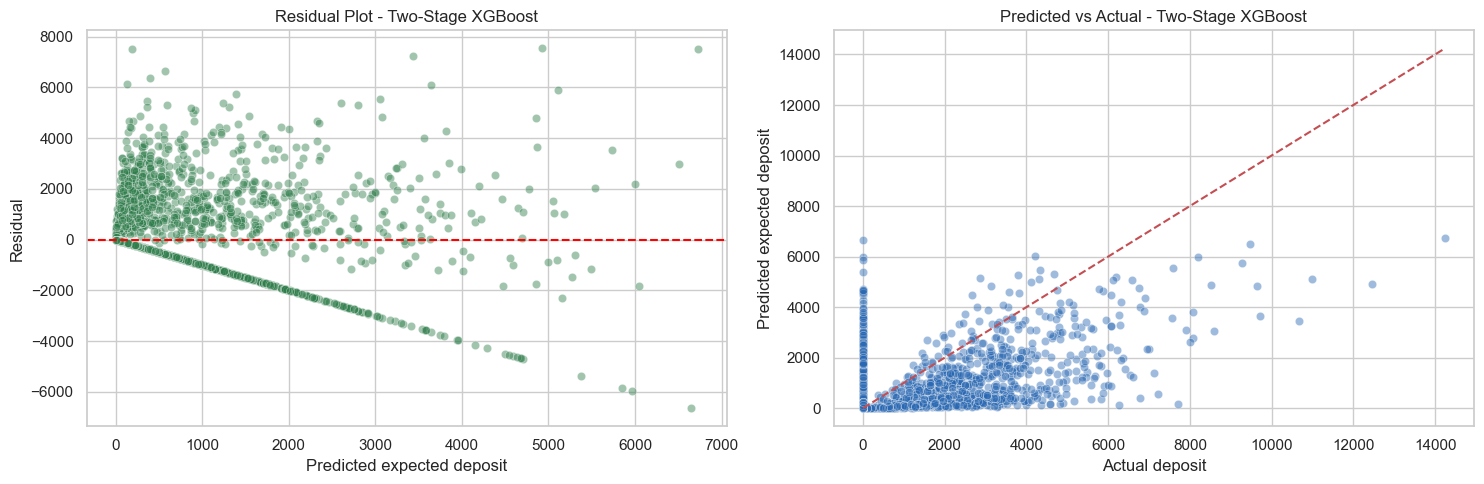

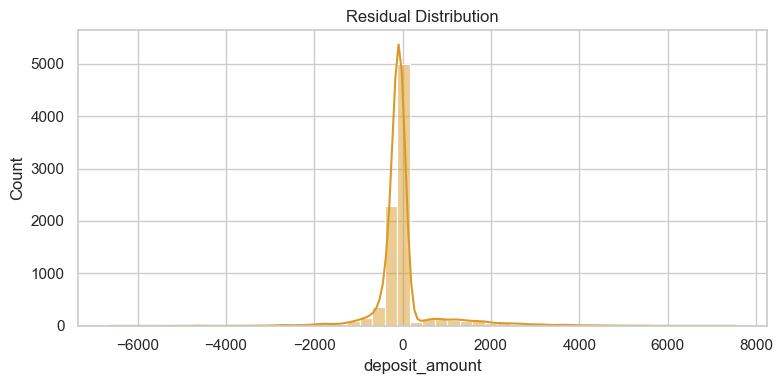

In [13]:
residuals = y_test - two_stage_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x=two_stage_pred, y=residuals, ax=axes[0], alpha=0.45, color="#2f7d4b")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residual Plot - Two-Stage XGBoost")
axes[0].set_xlabel("Predicted expected deposit")
axes[0].set_ylabel("Residual")

sns.scatterplot(x=y_test, y=two_stage_pred, ax=axes[1], alpha=0.45, color="#2867b2")
limit = max(y_test.max(), two_stage_pred.max())
axes[1].plot([0, limit], [0, limit], "r--")
axes[1].set_title("Predicted vs Actual - Two-Stage XGBoost")
axes[1].set_xlabel("Actual deposit")
axes[1].set_ylabel("Predicted expected deposit")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=50, kde=True, color="#d99a28")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

## Model Explainability

Linear coefficients, tree feature importance, permutation importance, and SHAP are used to explain model behavior.

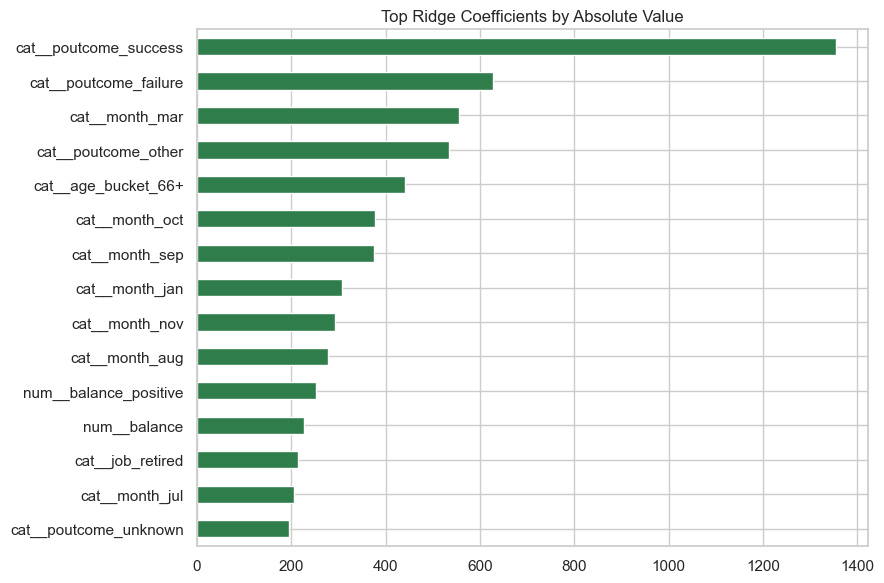

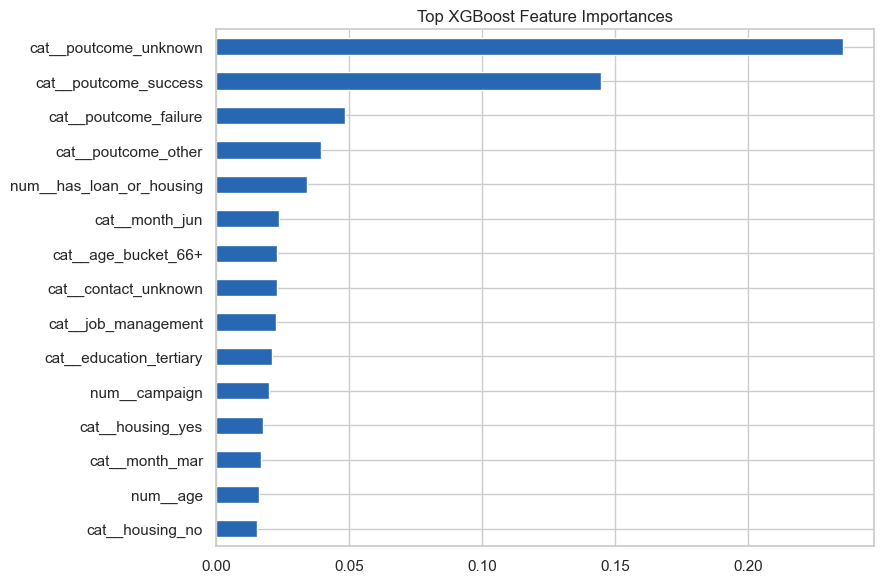

,permutation_importance
poutcome,0.151757
age,0.078286
campaign,0.066965
month,0.063734
balance,0.057056
pdays,0.029061
contact,0.025458
day,0.022032
job,0.014332
previous,0.009470


In [14]:
# Linear model coefficients
ridge_model = fitted_models["Ridge Regression"]
feature_names = ridge_model.named_steps["preprocess"].get_feature_names_out()
ridge_coef = pd.Series(ridge_model.named_steps["model"].coef_, index=feature_names)

plt.figure(figsize=(9, 6))
ridge_coef.abs().sort_values(ascending=False).head(15).sort_values().plot(kind="barh", color="#2f7d4b")
plt.title("Top Ridge Coefficients by Absolute Value")
plt.tight_layout()
plt.show()

# XGBoost importance from direct model
xgb_feature_names = direct_xgb.named_steps["preprocess"].get_feature_names_out()
xgb_importance = pd.Series(direct_xgb.named_steps["model"].feature_importances_, index=xgb_feature_names)
plt.figure(figsize=(9, 6))
xgb_importance.sort_values(ascending=False).head(15).sort_values().plot(kind="barh", color="#2867b2")
plt.title("Top XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# Permutation importance on a sample for speed
sample_idx = X_test.sample(n=min(2500, len(X_test)), random_state=RANDOM_STATE).index
perm = permutation_importance(direct_xgb, X_test.loc[sample_idx], y_test.loc[sample_idx], n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_importance = pd.Series(perm.importances_mean, index=FEATURE_COLUMNS)
display(perm_importance.sort_values(ascending=False).head(15).to_frame("permutation_importance"))

In [15]:
if SHAP_AVAILABLE:
    # Explain the positive-amount XGBoost model on transformed positive clients.
    shap_sample = X_test.sample(n=min(1200, len(X_test)), random_state=RANDOM_STATE)
    transformed = positive_regressor.named_steps["preprocess"].transform(
        positive_regressor.named_steps["features"].transform(shap_sample)
    )
    shap_feature_names = positive_regressor.named_steps["preprocess"].get_feature_names_out()
    explainer = shap.TreeExplainer(positive_regressor.named_steps["model"])
    shap_values = explainer.shap_values(transformed)

    shap.summary_plot(shap_values, transformed, feature_names=shap_feature_names, plot_type="bar", max_display=15, show=False)
    plt.title("SHAP Global Feature Importance - Positive Deposit Model")
    plt.tight_layout()
    plt.show()

    first_explanation = shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=transformed[0],
        feature_names=shap_feature_names,
    )
    shap.plots.waterfall(first_explanation, max_display=12, show=False)
    plt.title("SHAP Individual Explanation Example")
    plt.tight_layout()
    plt.show()
else:
    print("SHAP is not installed. Permutation importance above provides a model-agnostic explanation fallback.")

SHAP is not installed. Permutation importance above provides a model-agnostic explanation fallback.


## Campaign Strategy Simulation

The bank can contact only a limited share of clients. We rank all clients by predicted expected deposit and compare top-k targeting against random targeting.

,decile,clients,avg_predicted_deposit,total_predicted_deposit,actual_avg_deposit,actual_total_deposit,subscription_rate
0,1,4522,"1,760.38","7,960,458","1,850.27","8,366,919",52.01%
1,2,4521,416.95,"1,885,052",443.14,"2,003,440",19.97%
2,3,4521,227.66,"1,029,246",196.93,"890,321",10.11%
3,4,4521,156.07,"705,597",137.71,"622,571",7.96%
4,5,4521,115.24,"521,002",91.81,"415,079",5.99%
5,6,4521,86.76,"392,249",71.42,"322,877",5.62%
6,7,4520,64.69,"292,396",53.01,"239,607",4.69%
7,8,4522,45.77,"206,954",35.93,"162,463",3.98%
8,9,4521,28.58,"129,227",25.52,"115,396",3.61%
9,10,4521,10.17,"45,971",12.36,"55,885",3.03%


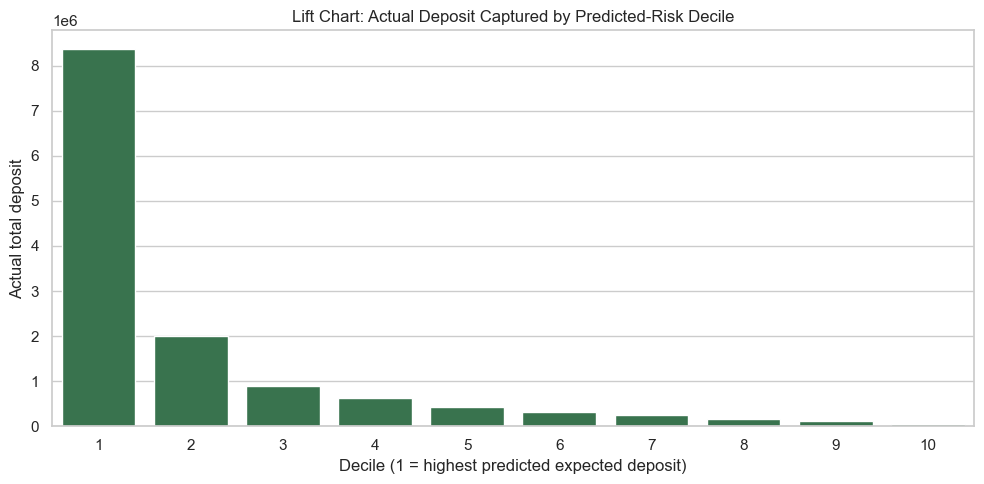

In [16]:
all_prob = subscription_clf.predict_proba(X)[:, 1]
all_positive_amount = np.clip(positive_regressor.predict(X), 0, None)
df_strategy = df.copy()
df_strategy["predicted_deposit"] = all_prob * all_positive_amount

df_ranked = df_strategy.sort_values("predicted_deposit", ascending=False).reset_index(drop=True)
df_ranked["decile"] = pd.qcut(df_ranked["predicted_deposit"].rank(method="first", ascending=False), 10, labels=False) + 1

decile_summary = (
    df_ranked.groupby("decile")
    .agg(
        clients=("deposit_amount", "size"),
        avg_predicted_deposit=("predicted_deposit", "mean"),
        total_predicted_deposit=("predicted_deposit", "sum"),
        actual_avg_deposit=("deposit_amount", "mean"),
        actual_total_deposit=("deposit_amount", "sum"),
        subscription_rate=("subscribed", "mean"),
    )
    .reset_index()
    .sort_values("decile")
)

display(decile_summary.style.format({
    "avg_predicted_deposit": "{:,.2f}",
    "total_predicted_deposit": "{:,.0f}",
    "actual_avg_deposit": "{:,.2f}",
    "actual_total_deposit": "{:,.0f}",
    "subscription_rate": "{:.2%}",
}))

plt.figure(figsize=(10, 5))
sns.barplot(data=decile_summary, x="decile", y="actual_total_deposit", color="#2f7d4b")
plt.title("Lift Chart: Actual Deposit Captured by Predicted-Risk Decile")
plt.xlabel("Decile (1 = highest predicted expected deposit)")
plt.ylabel("Actual total deposit")
plt.tight_layout()
plt.show()

,Strategy,Clients Contacted,Expected Total Deposit,Actual Total Deposit,Avg Expected Return per Contact,Actual Return per Contact
0,Top 10%,4521,"7,959,806","8,366,919","1,760.63","1,850.68"
1,Top 20%,9042,"9,845,225","10,370,358","1,088.83","1,146.91"
2,Random 20%,9042,"2,677,451","2,830,673",296.11,313.06


Top 20% targeting captures 3.66x the actual deposit value of random 20% targeting.


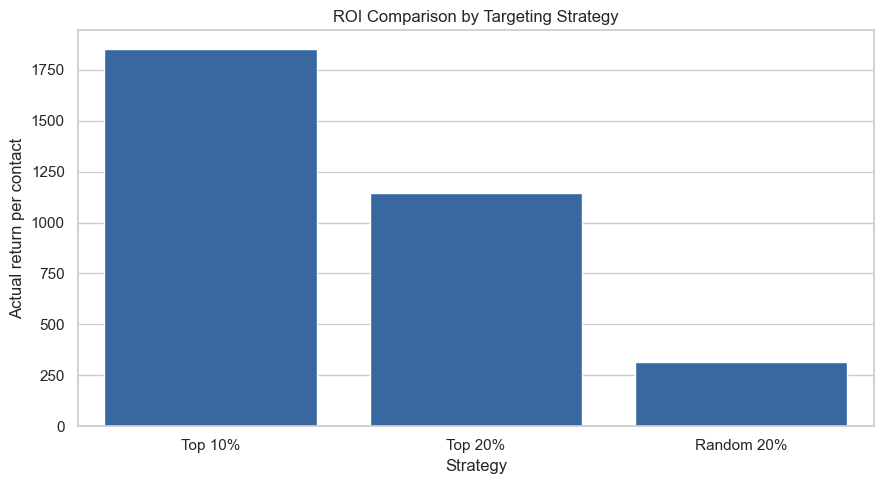

In [17]:
def summarize_strategy(name, group):
    return {
        "Strategy": name,
        "Clients Contacted": len(group),
        "Expected Total Deposit": group["predicted_deposit"].sum(),
        "Actual Total Deposit": group["deposit_amount"].sum(),
        "Avg Expected Return per Contact": group["predicted_deposit"].mean(),
        "Actual Return per Contact": group["deposit_amount"].mean(),
    }

n_clients = len(df_ranked)
top_10 = df_ranked.head(int(0.10 * n_clients))
top_20 = df_ranked.head(int(0.20 * n_clients))
random_20 = df_ranked.sample(n=int(0.20 * n_clients), random_state=RANDOM_STATE)

strategy_summary = pd.DataFrame([
    summarize_strategy("Top 10%", top_10),
    summarize_strategy("Top 20%", top_20),
    summarize_strategy("Random 20%", random_20),
])

display(strategy_summary.style.format({
    "Expected Total Deposit": "{:,.0f}",
    "Actual Total Deposit": "{:,.0f}",
    "Avg Expected Return per Contact": "{:,.2f}",
    "Actual Return per Contact": "{:,.2f}",
}))

top20_actual = strategy_summary.loc[strategy_summary["Strategy"] == "Top 20%", "Actual Total Deposit"].iloc[0]
random20_actual = strategy_summary.loc[strategy_summary["Strategy"] == "Random 20%", "Actual Total Deposit"].iloc[0]
uplift = top20_actual / random20_actual
print(f"Top 20% targeting captures {uplift:.2f}x the actual deposit value of random 20% targeting.")

plt.figure(figsize=(9, 5))
sns.barplot(data=strategy_summary, x="Strategy", y="Actual Return per Contact", color="#2867b2")
plt.title("ROI Comparison by Targeting Strategy")
plt.ylabel("Actual return per contact")
plt.tight_layout()
plt.show()

## Recommendation

The bank should prioritize the top 20% of clients ranked by predicted expected deposit when the campaign budget is limited. This segment captures substantially more actual deposit value than random targeting while keeping outreach volume constrained.

The top 10% has the highest average return per contact, while the top 20% captures more total value. If the campaign objective is maximum efficiency, choose top 10%; if the objective is total deposit capture under the stated 20% budget, choose top 20%.